# Compact MLP Baseline: MFCC-40
Trains multilabel and binary UUV MLP baselines for normal, M-filtered, and W-filtered MFCC-40 data. Use a T4 GPU runtime.

In [2]:
import sys
from pathlib import Path

REPO_RAW_BASE_URL = "https://raw.githubusercontent.com/Nabuhodonozzor/uuv-detection/main"
COMMON_UTILS_FILE = "common_utils.py"
MODEL_UTILS_FILE = "mlp_utils.py"
MODEL_DIR = "Baselines"
common_dirs = [Path.cwd() / "utils", Path.cwd().parent / "utils", Path("/content/utils"), Path("/content/drive/MyDrive/STUDA/src/utils")]
model_dirs = [Path.cwd(), Path.cwd() / MODEL_DIR, Path.cwd().parent / MODEL_DIR, Path("/content") / MODEL_DIR, Path("/content/drive/MyDrive/STUDA/src") / MODEL_DIR]
common_dir = next((directory for directory in common_dirs if (directory / COMMON_UTILS_FILE).exists()), None)
model_dir = next((directory for directory in model_dirs if (directory / MODEL_UTILS_FILE).exists()), None)

if common_dir is None or model_dir is None:
    import urllib.request
    common_dir = Path("/content/utils")
    model_dir = Path("/content") / MODEL_DIR
    common_dir.mkdir(parents=True, exist_ok=True)
    model_dir.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(f"{REPO_RAW_BASE_URL}/utils/{COMMON_UTILS_FILE}", common_dir / COMMON_UTILS_FILE)
    urllib.request.urlretrieve(f"{REPO_RAW_BASE_URL}/{MODEL_DIR}/{MODEL_UTILS_FILE}", model_dir / MODEL_UTILS_FILE)

sys.path.insert(0, str(common_dir))
sys.path.insert(0, str(model_dir))
print(f"Using common utilities from: {common_dir}")
print(f"Using baseline utilities from: {model_dir}")


Using common utilities from: /content/utils
Using baseline utilities from: /content/Baselines


In [3]:
import pandas as pd
from IPython.display import display
from google.colab import files

from common_utils import configure_kaggle_access, evaluate_models_for_variants, extract_zip, plot_training_histories, prepare_mfcc_dataset_variants, save_keras_artifacts, train_keras_models_for_variants, zip_artifacts
from mlp_utils import build_mlp_models_for_variants, get_mlp_callbacks


In [4]:
DATASET_KEY = "mfcc40"
DATASET_LABEL = "MFCC-40"
DATASET_SLUG = "pawedyrda/mfcc12"
ARCHIVE_PATH = Path("/content/mfcc12.zip")
EPOCHS = 50
BATCH_SIZE = 64


In [5]:
configure_kaggle_access("Kaggle")
if not ARCHIVE_PATH.exists():
    !kaggle datasets download -d {DATASET_SLUG} -p /content
else:
    print(f"Reusing downloaded archive: {ARCHIVE_PATH}")
DATA_PATH = extract_zip(ARCHIVE_PATH, "/content")
print(f"Dataset extracted to: {DATA_PATH}")


Dataset URL: https://www.kaggle.com/datasets/pawedyrda/mfcc12
License(s): unknown
100% 837M/837M [00:50<00:00, 17.4MB/s] 

Dataset extracted to: /content/mfcc12


In [6]:
variants = prepare_mfcc_dataset_variants(DATA_PATH)
print("Normal train shape:", variants.normal.train_data.shape)
print("M train shape:", variants.m.train_data.shape)
print("W train shape:", variants.w.train_data.shape)


Scanning feature data in: /content/mfcc12
Found .npz files: 9527, skipped: 0
Loaded samples: 9527
X shape: (9527, 618, 40)
y shape: (9527, 17)
Scanning feature data in: /content/mfcc12 (UUV filter: M)
Found .npz files: 9527, skipped: 523
Loaded samples: 9004
X shape: (9004, 618, 40)
y shape: (9004, 17)
Scanning feature data in: /content/mfcc12 (UUV filter: W)
Found .npz files: 9527, skipped: 379
Loaded samples: 9148
X shape: (9148, 618, 40)
y shape: (9148, 17)
Normal train shape: (6096, 618, 40)
M train shape: (5762, 618, 40)
W train shape: (5854, 618, 40)


Training multilabel model for variant: normal
Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 13s 91ms/step - binary_accuracy: 0.9031 - loss: 0.2933 - pr_auc: 0.1943 - precision: 0.4340 - recall: 0.4507 - roc_auc: 0.7142 - val_binary_accuracy: 0.9447 - val_loss: 0.1433 - val_pr_auc: 0.5331 - val_precision: 0.7955 - val_recall: 0.4998 - val_roc_auc: 0.9184 - learning_rate: 0.0010
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - binary_accuracy: 0.9382 - loss: 0.1597 - pr_auc: 0.4038 - precision: 0.6640 - recall: 0.5558 - roc_auc: 0.8767 - val_binary_accuracy: 0.9507 - val_loss: 0.1191 - val_pr_auc: 0.6937 - val_precision: 0.7955 - val_recall: 0.5918 - val_roc_auc: 0.9532 - learning_rate: 0.0010
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - binary_accuracy: 0.9484 - loss: 0.1291 - pr_auc: 0.5145 - precision: 0.7389 - recall: 0.6106 - roc_auc: 0.9313 - val_binary_accuracy: 0.9559 - val_loss: 0.1085 - val_pr_auc: 0.7261 - val_precision: 0.8159 - val_recall: 0.6449 - val_roc_auc: 0.9619 - le

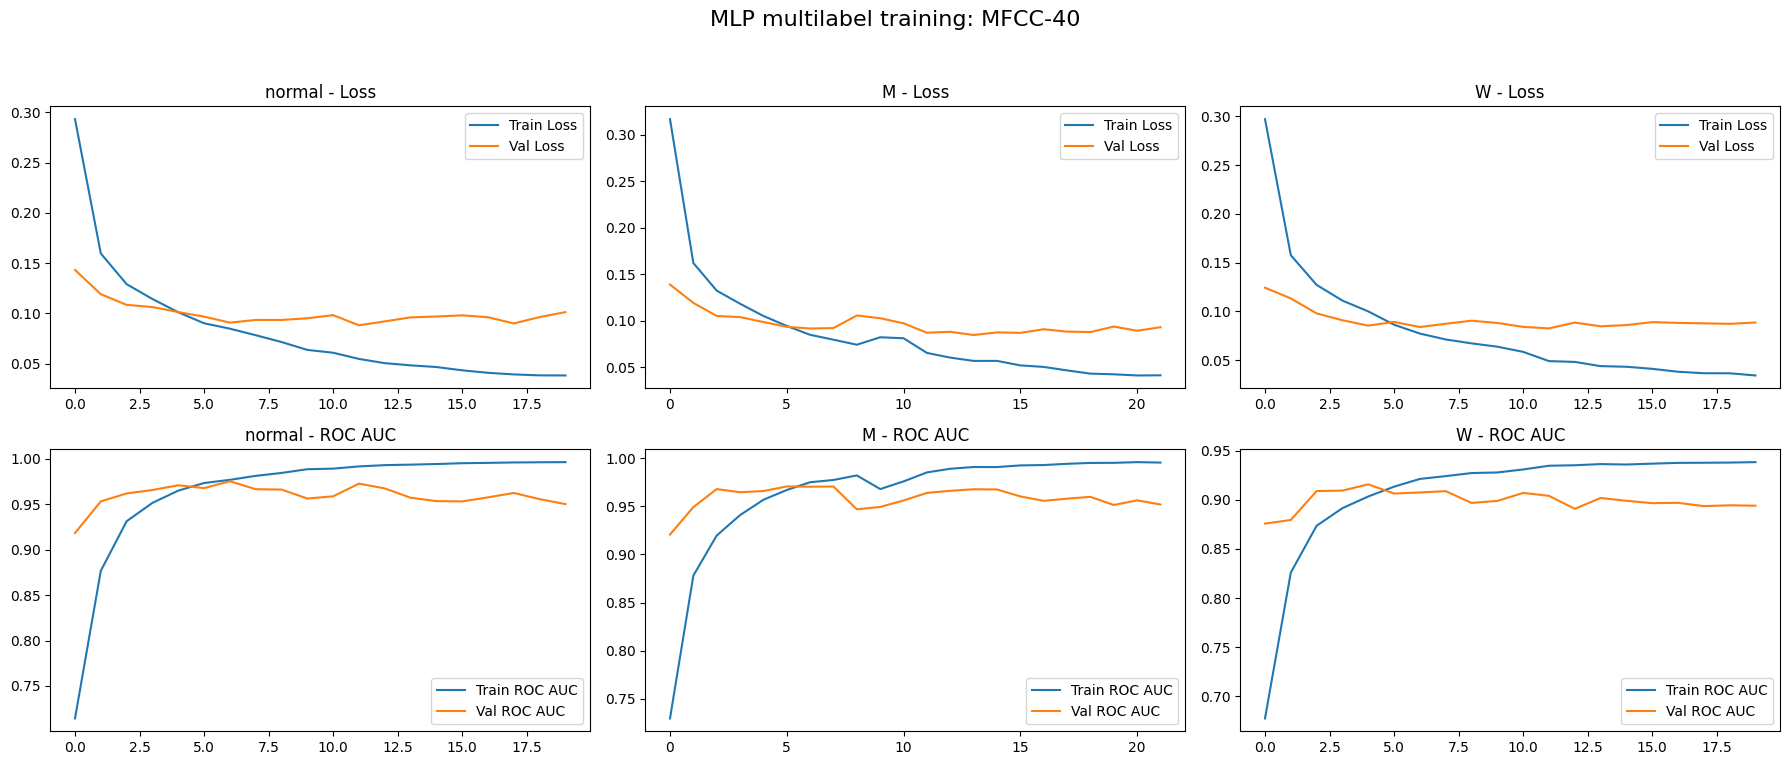

Training binary model for variant: normal
Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - binary_accuracy: 0.9042 - loss: 0.6527 - pr_auc: 0.3723 - precision: 0.4551 - recall: 0.2839 - roc_auc: 0.8051 - val_binary_accuracy: 0.9482 - val_loss: 0.1517 - val_pr_auc: 0.8090 - val_precision: 0.8646 - val_recall: 0.5570 - val_roc_auc: 0.9669 - learning_rate: 0.0010
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - binary_accuracy: 0.9488 - loss: 0.1217 - pr_auc: 0.8272 - precision: 0.9199 - recall: 0.4774 - roc_auc: 0.9696 - val_binary_accuracy: 0.9541 - val_loss: 0.1000 - val_pr_auc: 0.9128 - val_precision: 0.9877 - val_recall: 0.5369 - val_roc_auc: 0.9874 - learning_rate: 0.0010
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - binary_accuracy: 0.9619 - loss: 0.0900 - pr_auc: 0.8985 - precision: 0.9235 - recall: 0.6329 - roc_auc: 0.9861 - val_binary_accuracy: 0.9639 - val_loss: 0.0848 - val_pr_auc: 0.9370 - val_precision: 0.9700 - val_recall: 0.6510 - val_roc_auc: 0.9919 - learnin

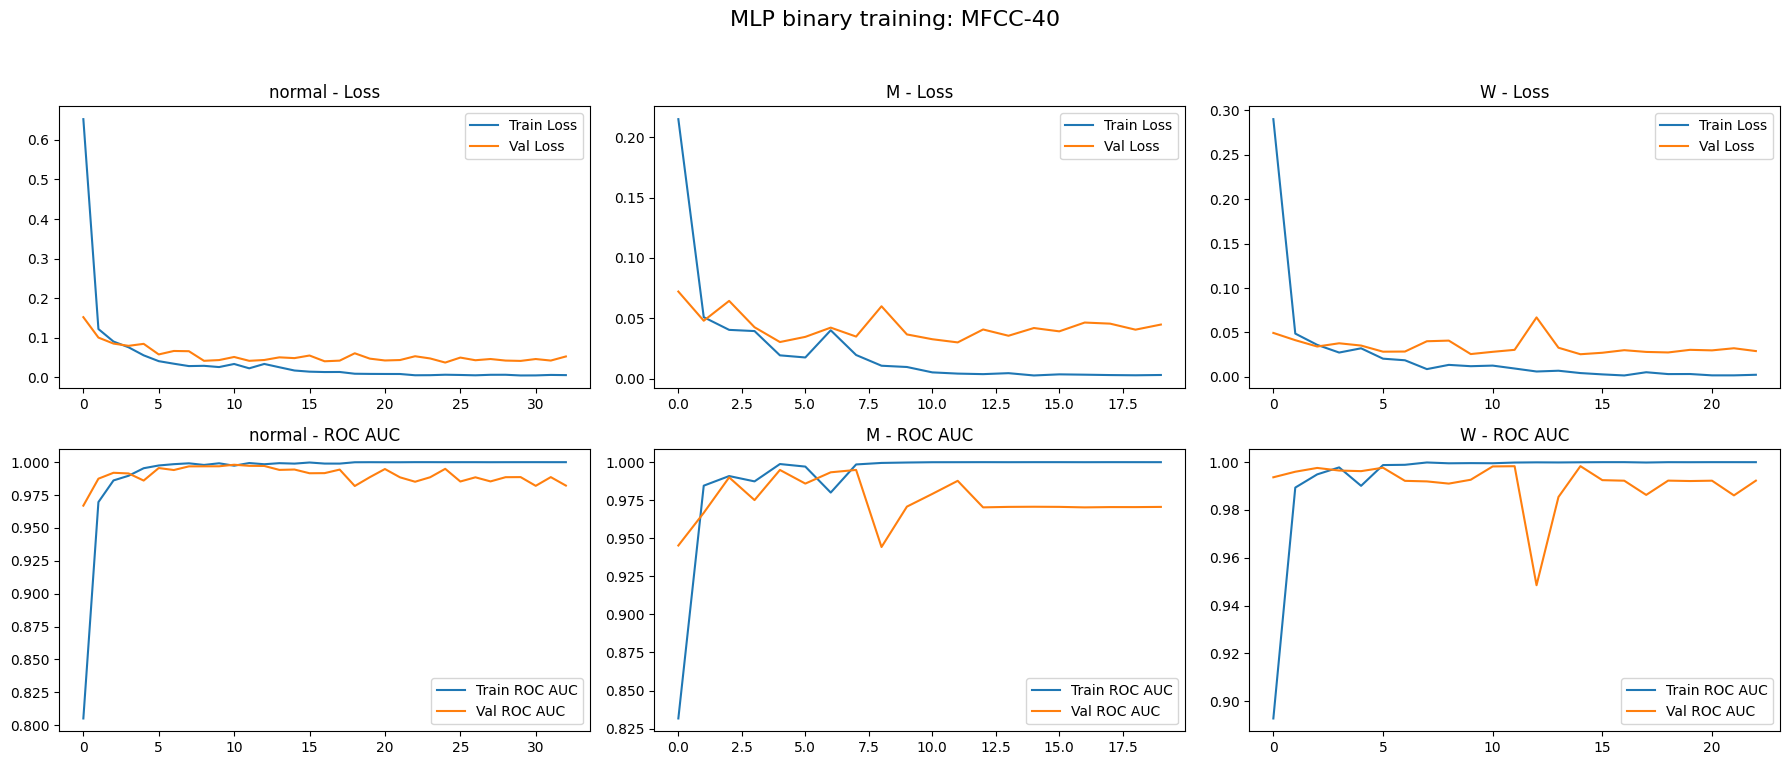

In [7]:
multilabel_models = build_mlp_models_for_variants(variants, model_type="multilabel")
multilabel_histories = train_keras_models_for_variants(multilabel_models, variants, "multilabel", EPOCHS, BATCH_SIZE, get_mlp_callbacks)
plot_training_histories(multilabel_histories, f"MLP multilabel training: {DATASET_LABEL}")

binary_models = build_mlp_models_for_variants(variants, model_type="binary")
binary_histories = train_keras_models_for_variants(binary_models, variants, "binary", EPOCHS, BATCH_SIZE, get_mlp_callbacks)
plot_training_histories(binary_histories, f"MLP binary training: {DATASET_LABEL}")


In [8]:
multilabel_results = evaluate_models_for_variants(multilabel_models, variants, "multilabel", DATASET_LABEL)
binary_results = evaluate_models_for_variants(binary_models, variants, "binary", DATASET_LABEL)
comparison_results = pd.concat([multilabel_results.assign(task="multilabel"), binary_results.assign(task="binary")], ignore_index=True)
display(comparison_results[["task", "Model", "precision", "recall", "f1-score", "support"]])



--- Evaluation for: Multilabel normal MFCC-40 ---

                   precision    recall  f1-score   support

ArtificialSignals       0.98      0.82      0.89       214
 BigPassengerShip       1.00      0.05      0.09        22
            Cargo       0.50      0.06      0.11        49
         FishBoat       0.92      0.78      0.85        46
        GreenCity       0.95      0.60      0.74        98
           KaiYan       1.00      0.33      0.50        21
          KaiYuan       0.75      0.56      0.64       257
        MotorBoat       0.88      0.27      0.41        26
              No7       0.90      0.50      0.64       143
       PoliceBoat       1.00      0.05      0.09        22
          QianDao       0.88      0.67      0.76       680
        SpeedBoat       0.84      0.83      0.83       836
          TheEarl       0.95      0.88      0.91       103
        TheKnight       0.95      0.65      0.77        62
              UUV       0.97      0.82      0.89       200
   

,task,Model,precision,recall,f1-score,support
0,multilabel,Multilabel normal MFCC-40,0.970588,0.825000,0.891892,200.0
1,multilabel,Multilabel M MFCC-40,0.969697,0.727273,0.831169,88.0
2,multilabel,Multilabel W MFCC-40,0.960000,0.705882,0.813559,102.0
3,binary,Binary normal MFCC-40,0.963542,0.925000,0.943878,200.0
4,binary,Binary M MFCC-40,0.918605,0.897727,0.908046,88.0
5,binary,Binary W MFCC-40,0.956522,0.862745,0.907216,102.0


In [9]:
save_dir = save_keras_artifacts(f"/content/saved_artifacts/mlp_{DATASET_KEY}", DATASET_KEY, multilabel_models, binary_models, multilabel_histories, binary_histories, multilabel_results, binary_results)
comparison_results.to_csv(save_dir / f"mlp_comparison_{DATASET_KEY}.csv", index=False)
archive_path = zip_artifacts(save_dir, f"/content/mlp_models_and_results_{DATASET_KEY}.zip")
files.download(str(archive_path))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>